Bitcoin Address: 1AJbsFZ64EpEfS5UAjAfcUG8pH8Jn3rn1F

🚨 Suspicious Patterns Found:
 - Peel Chain in transaction 599e47a8114fe098103663029548811d2651991b62397e057f0c863c2bc9f9ea

Graph nodes: 13
Graph edges: 22


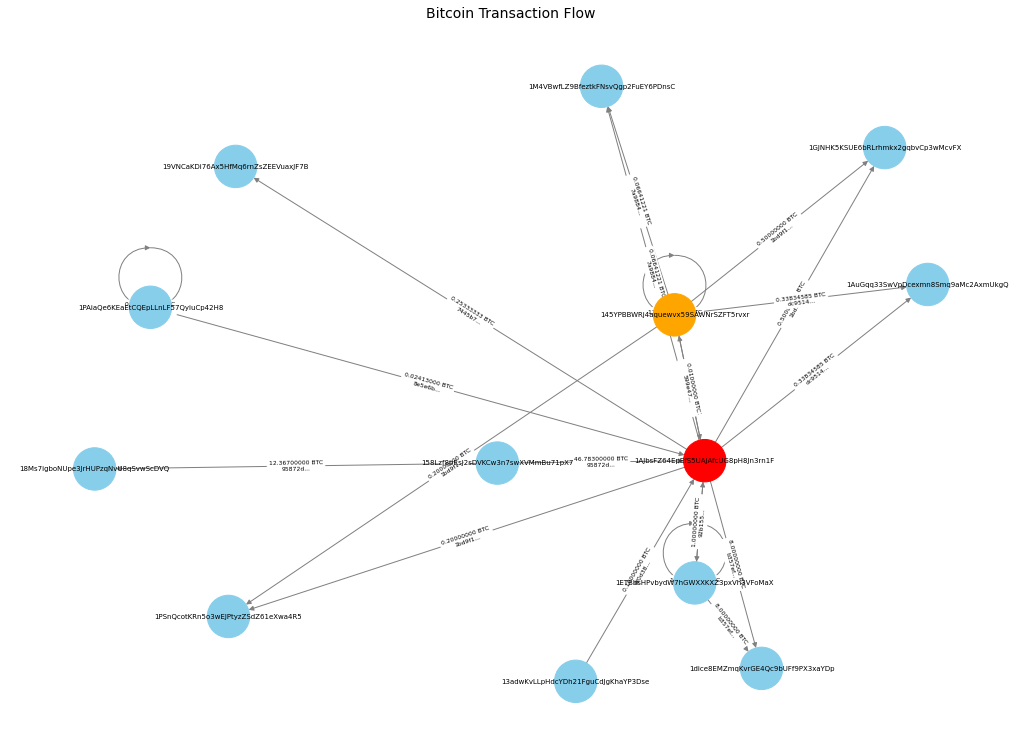

✅ Graph saved as btc_suspicious_graph.png


In [2]:
import requests
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Fetch transactions
def fetch_transactions(address):
    url = f"https://api.blockcypher.com/v1/btc/main/addrs/{address}/full"
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    else:
        raise Exception(f"Error fetching transactions: {response.text}")

# Step 2: Analyze suspicious patterns
def analyze_patterns(data):
    suspicious = []
    txs = data.get("txs", [])

    for tx in txs:
        inputs = tx.get("inputs", [])
        outputs = tx.get("outputs", [])

        # Fan-in
        if len(inputs) > 2 and len(outputs) == 1:
            suspicious.append(("Fan-In", tx["hash"], inputs, outputs))

        # Fan-out
        if len(inputs) == 1 and len(outputs) > 5:
            suspicious.append(("Fan-Out", tx["hash"], inputs, outputs))

        # Mixing
        if len(inputs) > 3 and len(outputs) > 3:
            suspicious.append(("Mixing", tx["hash"], inputs, outputs))

        # Peel chain
        if len(inputs) == 1 and len(outputs) == 2:
            values = [out["value"] for out in outputs if "value" in out]
            if values:
                big, small = max(values), min(values)
                if big > 10 * small:
                    suspicious.append(("Peel Chain", tx["hash"], inputs, outputs))

    return suspicious

# Step 3: Build graph
def build_graph(data, suspicious_patterns):
    G = nx.DiGraph()
    suspicious_nodes = set()

    for tx in data.get("txs", []):
        txid = tx["hash"]

        for inp in tx.get("inputs", []):
            addr_in = inp.get("addresses", ["Unknown"])[0]
            for out in tx.get("outputs", []):
                addr_out = out.get("addresses", ["Unknown"])[0]
                value = out.get("value", 0) / 1e8  # BTC
                G.add_edge(addr_in, addr_out,
                           weight=value,
                           label=f"{value:.8f} BTC\n{txid[:6]}...")

    # Mark suspicious addresses
    for ptype, txid, ins, outs in suspicious_patterns:
        for i in ins:
            suspicious_nodes.add(i.get("addresses", ["Unknown"])[0])
        for o in outs:
            suspicious_nodes.add(o.get("addresses", ["Unknown"])[0])

    return G, suspicious_nodes

# Step 4: Plot graph
def plot_graph(G, main_address, suspicious_addrs=set(), filename="btc_graph.png"):
    if G.number_of_nodes() == 0:
        print("⚠️ No graph data to plot.")
        return

    color_map = []
    for node in G.nodes():
        if node == main_address:
            color_map.append("red")        # Main address
        elif node in suspicious_addrs:
            color_map.append("orange")     # Suspicious
        else:
            color_map.append("skyblue")    # Normal

    pos = nx.spring_layout(G, k=0.5, iterations=50)
    plt.figure(figsize=(14, 10))

    nx.draw(G, pos, with_labels=True, node_size=1800,
            node_color=color_map, font_size=7, arrows=True, edge_color="gray")

    # ✅ FIX: use "label" instead of "weight"
    edge_labels = {(u, v): d.get("label", "") for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

    plt.title("Bitcoin Transaction Flow", fontsize=14)
    plt.savefig(filename, format="png", dpi=300)
    plt.show()
    print(f"✅ Graph saved as {filename}")

# ---------------- MAIN ----------------
if __name__ == "__main__":
    btc_address = "1AJbsFZ64EpEfS5UAjAfcUG8pH8Jn3rn1F"
    print("Bitcoin Address:", btc_address)

    # Fetch transactions
    tx_data = fetch_transactions(btc_address)

    # Analyze suspicious patterns
    suspicious_patterns = analyze_patterns(tx_data)
    if suspicious_patterns:
        print("\n🚨 Suspicious Patterns Found:")
        for ptype, txid, _, _ in suspicious_patterns:
            print(f" - {ptype} in transaction {txid}")
    else:
        print("\n✅ No major suspicious patterns detected.")

    # Build & plot graph
    G, suspicious_addrs = build_graph(tx_data, suspicious_patterns)
    print("\nGraph nodes:", G.number_of_nodes())
    print("Graph edges:", G.number_of_edges())
    plot_graph(G, btc_address, suspicious_addrs, "btc_suspicious_graph.png")
